# Example runtime and memory

Current `curated` and `img` database profiles on the bundled assembly. Trial 0 is a warm-up and is not included in the medians.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'mkdocs.yml').is_file():
            return candidate
    raise FileNotFoundError('could not locate mkdocs.yml')


ROOT = find_project_root(Path.cwd().resolve())
DATA = ROOT / 'docs' / 'data' / 'example_performance.tsv'
FIGURES = ROOT / 'docs' / 'assets' / 'figures'
sys.path.insert(0, str(ROOT / 'notebooks'))
from beautiful_style import finalize_axes, set_beautiful_style

set_beautiful_style(medium='paper', background='light', dpi=180)
plt.rcParams['svg.hashsalt'] = 'ssuextract-docs'
plt.ioff();

In [2]:
measurements = pd.read_csv(DATA, sep='\t')
required = {'profile', 'trial', 'warmup', 'elapsed_seconds', 'peak_rss_kb'}
assert set(measurements.columns) == required
assert list(measurements['profile'].drop_duplicates()) == ['curated', 'img']
assert measurements.groupby('profile').size().eq(4).all()
assert measurements.groupby('profile')['warmup'].sum().eq(1).all()
assert measurements['elapsed_seconds'].gt(0).all()
assert measurements['peak_rss_kb'].gt(0).all()

measured = measurements.loc[~measurements['warmup']].copy()
assert measured.groupby('profile').size().eq(3).all()
measured['peak_rss_gib'] = measured['peak_rss_kb'] / 1024**2
summary = (
    measured.groupby('profile', sort=False)
    .agg(
        measured_runs=('trial', 'size'),
        median_seconds=('elapsed_seconds', 'median'),
        median_max_rss_gib=('peak_rss_gib', 'median'),
    )
    .reset_index()
)
display(summary.round({'median_seconds': 2, 'median_max_rss_gib': 3}))

,profile,measured_runs,median_seconds,median_max_rss_gib
0,curated,3,55.01,2.786
1,img,3,72.60,2.789


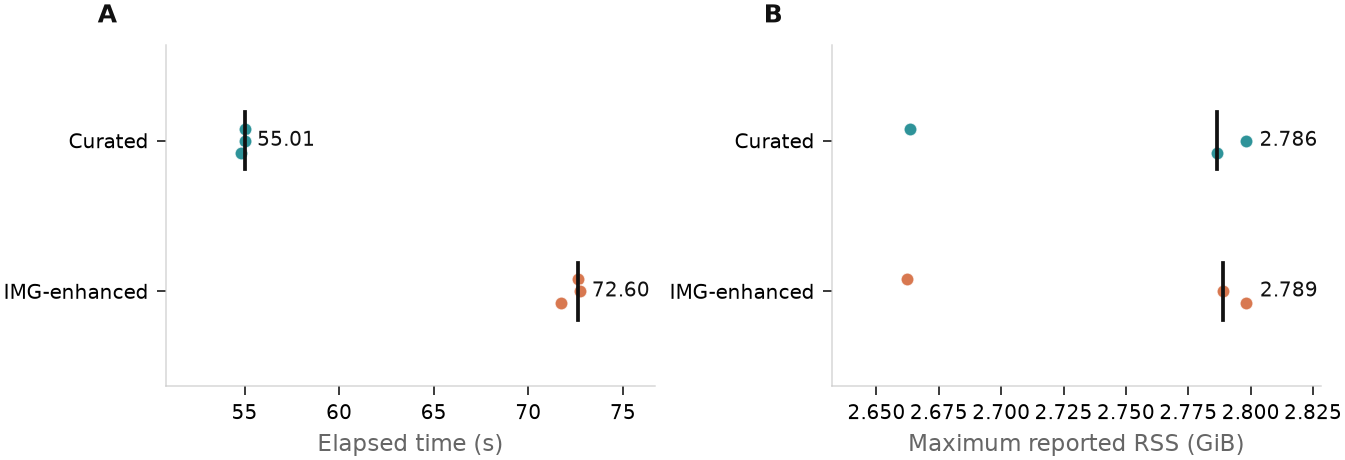

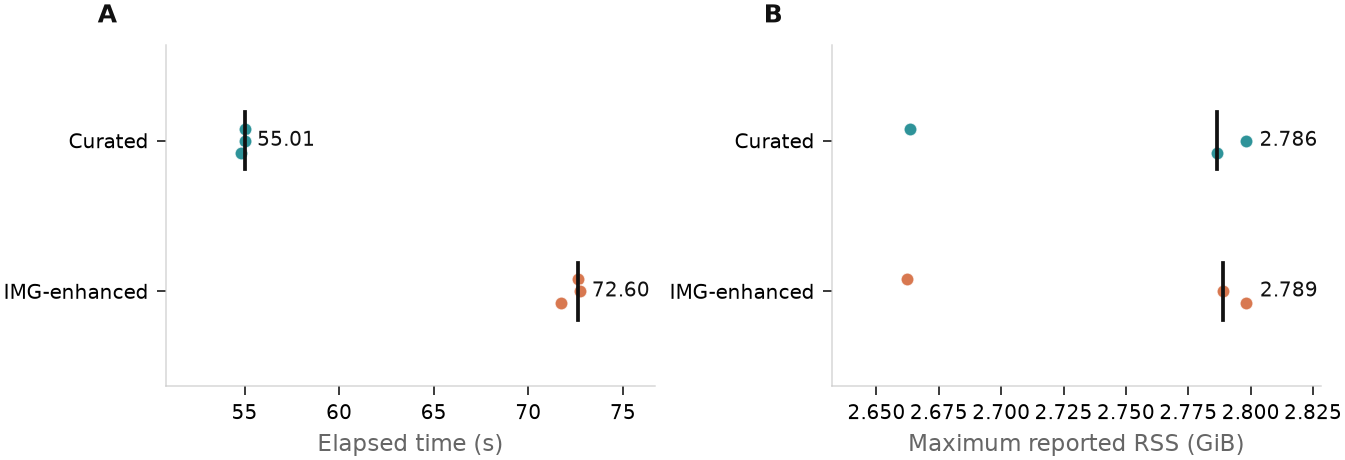

In [3]:
labels = {'curated': 'Curated', 'img': 'IMG-enhanced'}
colors = {'curated': '#007C83', 'img': '#D05A2A'}
panels = [
    ('elapsed_seconds', 'Elapsed time (s)', '{:.2f}'),
    ('peak_rss_gib', 'Maximum reported RSS (GiB)', '{:.3f}'),
]

fig, axes = plt.subplots(1, 2, figsize=(7.4, 2.6), constrained_layout=True)
for panel, ax, (column, xlabel, number_format) in zip(('A', 'B'), axes, panels):
    values_all = measured[column].to_numpy()
    label_offset = max(np.ptp(values_all) * 0.035, np.median(values_all) * 0.002)
    for y, profile in enumerate(labels):
        values = measured.loc[measured['profile'].eq(profile), column].to_numpy()
        offsets = np.linspace(-0.08, 0.08, len(values))
        ax.scatter(
            values,
            y + offsets,
            s=27,
            color=colors[profile],
            alpha=0.82,
            edgecolor='white',
            linewidth=0.5,
            zorder=3,
        )
        median = float(np.median(values))
        ax.plot([median, median], [y - 0.19, y + 0.19], color='#111111', linewidth=1.5, zorder=4)
        ax.text(max(values) + label_offset, y, number_format.format(median), va='center', fontsize=8)
    ax.set_yticks(range(len(labels)), labels.values())
    ax.invert_yaxis()
    ax.margins(x=0.22, y=0.32)
    finalize_axes(ax, xlabel=xlabel)
    ax.text(-0.14, 1.05, panel, transform=ax.transAxes, fontsize=10, fontweight='bold', va='bottom')

metadata = {'Date': None, 'Creator': 'SSUextract'}
svg = FIGURES / 'example-performance.svg'
png = FIGURES / 'example-performance.png'
fig.savefig(svg, metadata=metadata)
svg_text = svg.read_text(encoding='utf-8')
svg.write_text('\n'.join(line.rstrip() for line in svg_text.splitlines()) + '\n', encoding='utf-8')
fig.savefig(png, dpi=600, metadata=metadata)
svg.chmod(0o644)
png.chmod(0o644)
fig